# Multiple Stations

In [11]:
# Import Packages
from __future__ import annotations
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pymap3d as pm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display, HTML

import os
import sys
import imageio.v2 as imageio

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from geopy.distance import great_circle
from scipy.interpolate import CubicSpline

%reload_ext autoreload
%autoreload 2

# import pykrige

In [12]:
import sys
from pathlib import Path

# --------------------------------------------------
# Project paths
# --------------------------------------------------
# Expected repository structure:
# bachelor-gnss-ionosphere-code/
# ├── Functions/
# ├── notebooks/
# └── data/

PROJECT_ROOT = Path.cwd().parent
FUNCTIONS_DIR = PROJECT_ROOT / "Functions"

if not FUNCTIONS_DIR.exists():
    raise FileNotFoundError(
        f"Functions directory not found: {FUNCTIONS_DIR}\n"
        "Check that the notebook is placed in the 'notebooks/' folder "
        "and that the Python files are placed in 'Functions/'."
    )

if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(FUNCTIONS_DIR))


# --------------------------------------------------
# Import project functions
# --------------------------------------------------
from collective0 import (
    build_ipp_validation_df,
    ipp_pipeline_one_station
)

from ipp_on_map import (
    plot_ipp_difference_magnitude,
    plot_ipp_map_geodetic,
    plot_ipp_sp3,
    plot_ipp_sp3_colored_by_time,
    make_ipp_sp3_gif,
    compute_geodetic_differences_ipp
)


# --------------------------------------------------
# Data paths
# --------------------------------------------------
DATA_DIR = PROJECT_ROOT.parent / "Data"
STATION_DIR = DATA_DIR 
ISMR_DIR = DATA_DIR / "ISMR"
SP3_DIR = DATA_DIR 

path_stations = STATION_DIR / "All_stations.csv"

path1 = ISMR_DIR / "26019" / "KLQ2019t00.26_.ismr" / "KLQ2019t00.26_.ismr"
path2 = ISMR_DIR / "26019" / "KLQ2019t15.26_.ismr" / "KLQ2019t15.26_.ismr"
path3 = ISMR_DIR / "26019" / "KLQ2019t30.26_.ismr" / "KLQ2019t30.26_.ismr"

path_sp3 = SP3_DIR / "COD0OPSFIN_20260190000_01D_05M_ORB.SP3"


# --------------------------------------------------
# Check input files
# --------------------------------------------------
required_paths = [
    path_stations,
    path1,
    path2,
    path3,
    path_sp3
]

missing_paths = [p for p in required_paths if not p.exists()]

if missing_paths:
    print("Some input files are missing:")
    for p in missing_paths:
        print(" -", p)

    print("\nRaw SP3 and ISMR data are not included in the GitHub repository.")
    print("Place the required files in the data/ folder using the structure described in data/README.md.")
else:
    print("All input files found.")

All input files found.


In [13]:
# sys.path.insert(0, r"C:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Analysis\Functions")
# from collective0 import build_ipp_validation_df, ipp_pipeline_one_station
# from ipp_on_map import plot_ipp_difference_magnitude, plot_ipp_map_geodetic, plot_ipp_sp3, plot_ipp_sp3_colored_by_time, make_ipp_sp3_gif, compute_geodetic_differences_ipp

# path_stations = r"C:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data\All_stations.csv"
# path1 = r"C:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data\ISMR\26019\KLQ2019t00.26_.ismr\KLQ2019t00.26_.ismr"
# path2 = r"C:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data\ISMR\26019\KLQ2019t15.26_.ismr\KLQ2019t15.26_.ismr"
# path3 = r"C:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data\ISMR\26019\KLQ2019t30.26_.ismr\KLQ2019t30.26_.ismr"
# path_sp3 = r"C:\Users\mievk\Danmarks Tekniske Universitet\Sarah Schultz Beeck - Mie Bachelor\Data\COD0OPSFIN_20260190000_01D_05M_ORB.SP3"

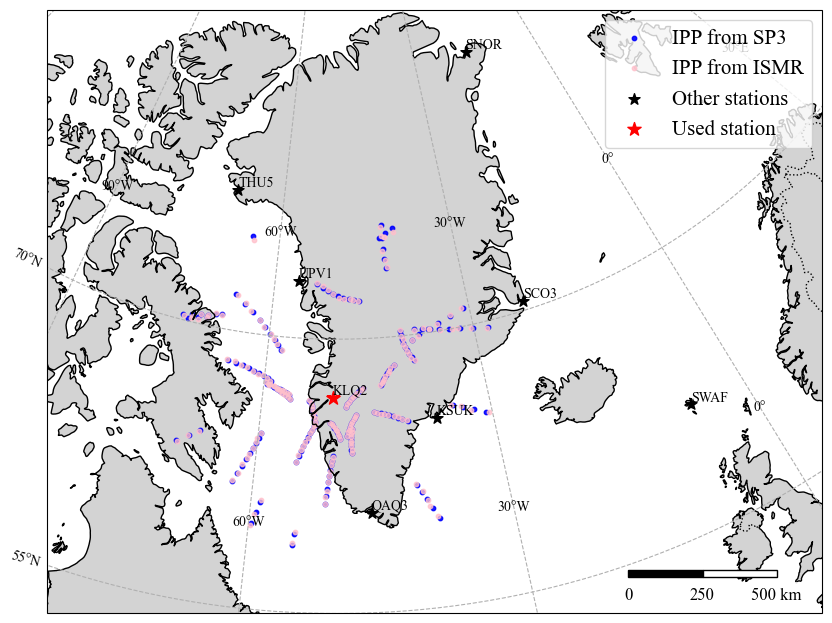

In [14]:
elevation_mask = 15
h_ion = 350_000.0
R_E = 6_378_137.0
one_station = "KLQ2"
paths_ismr = [path1, path2, path3]
spline = False #True/False

df_val, lat, lon = ipp_pipeline_one_station(elevation_mask, R_E, h_ion, path_stations, one_station, paths_ismr, path_sp3, use_spline=spline)
len(df_val)

plot_ipp_map_geodetic(df_val, path_stations=path_stations,active_stations=[one_station])
# plot_ipp_sp3(df_val, path_stations=path_stations,active_stations=[one_station])
# plot_ipp_difference_magnitude(df_val, path_stations=path_stations, active_stations=[one_station])

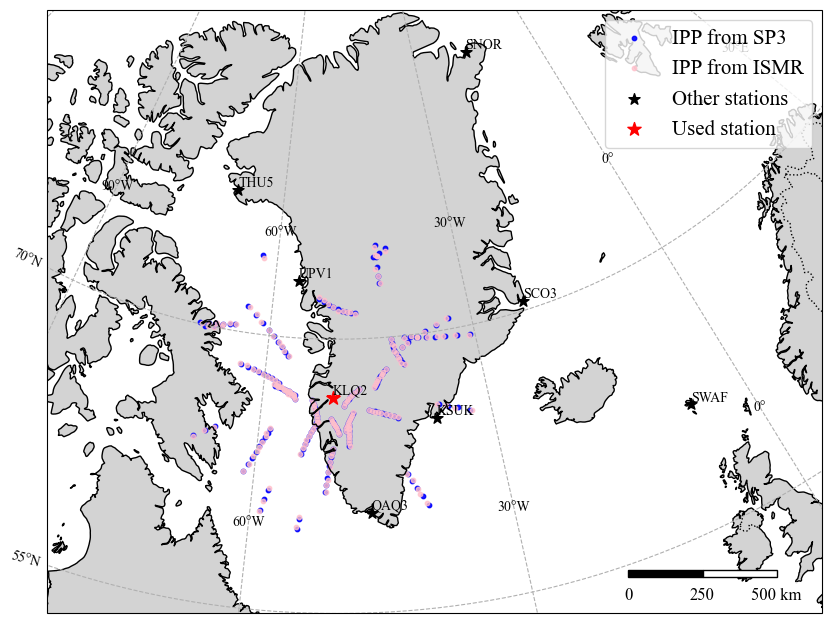

In [15]:
elevation_mask = 15
h_ion = 300_000.0
R_E = 6_378_137.0
one_station = "KLQ2"
paths_ismr = [path1, path2, path3]
spline = False #True/False

df_val, lat, lon = ipp_pipeline_one_station(elevation_mask, R_E, h_ion, path_stations, one_station, paths_ismr, path_sp3, use_spline=spline)
len(df_val)

plot_ipp_map_geodetic(df_val, path_stations=path_stations,active_stations=[one_station])
# plot_ipp_sp3(df_val, path_stations=path_stations,active_stations=[one_station])
# plot_ipp_difference_magnitude(df_val, path_stations=path_stations, active_stations=[one_station])

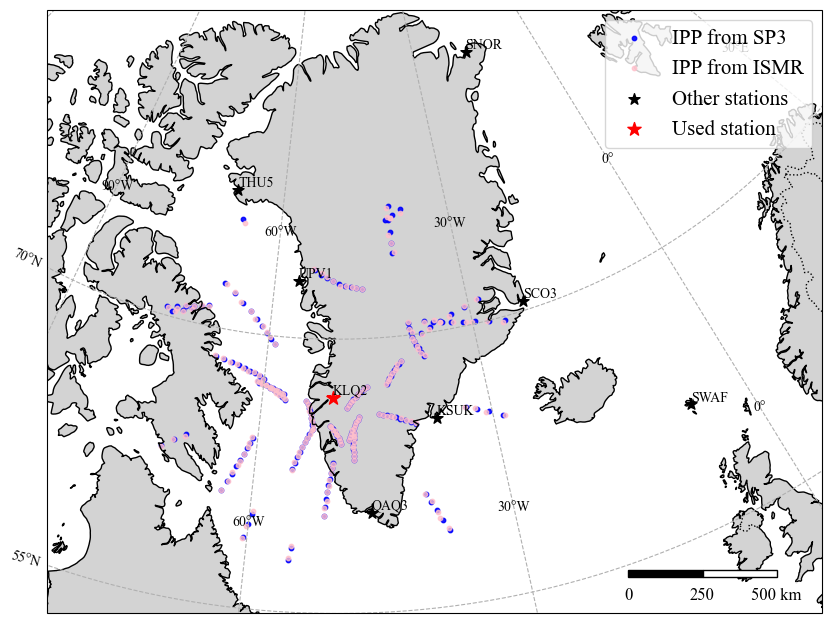

In [16]:
elevation_mask = 15
h_ion = 400_000.0
R_E = 6_378_137.0
one_station = "KLQ2"
paths_ismr = [path1, path2, path3]
spline = False #True/False

df_val3, lat, lon = ipp_pipeline_one_station(elevation_mask, R_E, h_ion, path_stations, one_station, paths_ismr, path_sp3, use_spline=spline)

plot_ipp_map_geodetic(df_val3, path_stations=path_stations,active_stations=[one_station])